In [5]:
# sequence and complement of DNA

from Bio.Seq import Seq
seq = Seq ("ATGCATGC")
print(seq)
rc = seq.complement()
print(rc)





ATGCATGC
TACGTACG


In [1]:
# Opening DNA file, unziping and printing: ID, Name, Description, Features, Seq, Phred quality.

from collections import defaultdict
import gzip
import seaborn as sns
import matplotlib.pyplot as plt
from Bio import SeqIO
import os
recs = SeqIO.parse(gzip.open(r'C:\Users\pedro\Desktop\PYTHON\Python projects\SRR003265.filt.fastq.gz', 'rt', encoding='utf-8'), 'fastq')
rec = next(recs)
print(rec)
print(rec.id, rec.description, rec.seq)
print(rec.letter_annotations)  # quality scores of our reads, per letter 





FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\pedro\\Desktop\\PYTHON\\Python projects\\SRR003265.filt.fastq.gz'

In [ ]:
# nucleotides percentage 
# N (base indefinida)  = usada quando o sequenciador não conseguiu determinar qual base está presente naquela posição da sequência.
# N” aparece quando a qualidade do sinal é baixa, por exemplo:
# Ruído durante o sequenciamento;
# Sobreposição de sinais (duas bases detectadas ao mesmo tempo)
# Erros na leitura ótica do sequenciador;
# Regiões com DNA de baixa qualidade ou concentração.
# Nucleotide Percentage


recs = SeqIO.parse(gzip.open(r'C:\Users\pedro\Desktop\PYTHON\Python projects\SRR003265.filt.fastq.gz', 'rt', encoding='utf-8'), 'fastq')
count = defaultdict(int)
for rec in recs:
    for letter in rec.seq:
        count[letter] += 1
tot = sum(count.values())
for letter, count in count.items():
    print('%s: %.2f %d' % (letter, 100. * count / tot, count))

G: 20.68 5359334
A: 28.60 7411965
C: 21.00 5444053
T: 29.58 7666885
N: 0.14 37289


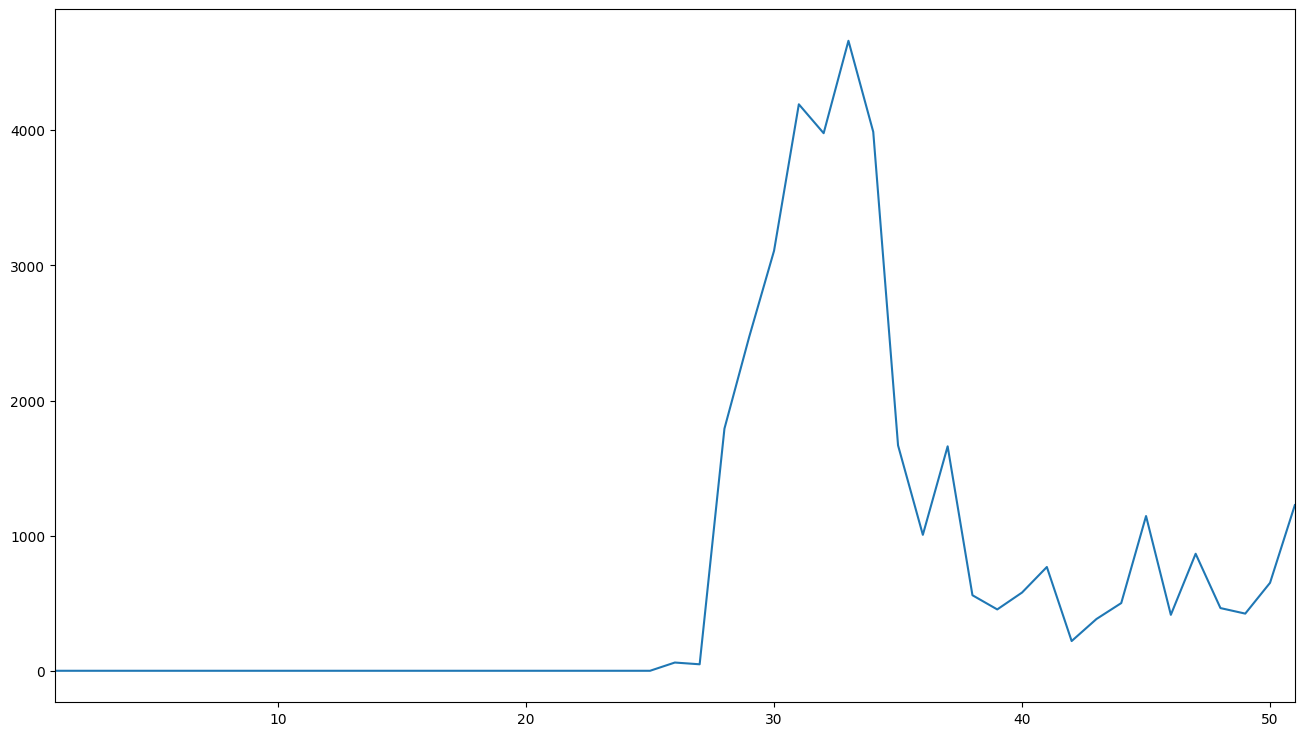

In [ ]:
# Esse código analisa um arquivo de sequenciamento (FASTQ) e conta quantas vezes a base “N” (indefinida) aparece em cada posição das leituras.
# serve para avaliar a qualidade do sequenciamento
# Depois, ele gera um gráfico da distribuição dos “N” ao longo da sequência.


recs = SeqIO.parse(gzip.open(r'C:\Users\pedro\Desktop\PYTHON\Python projects\SRR003265.filt.fastq.gz', 'rt', encoding='UTF-8'), 'fastq')
n_cnt = defaultdict(int)
for rec in recs:
    for i, letter in enumerate(rec.seq):
        pos = i + 1
        if letter == 'N':
            n_cnt[pos] += 1
seq_len = max(n_cnt.keys())
positions = range(1, seq_len + 1)
fig, ax = plt.subplots(figsize=(16,9))
ax.plot(positions, [n_cnt[x] for x in positions])
ax.set_xlim(1, seq_len)
pass

In [ ]:
# A distância de Hamming mede quantas posições diferentes existem entre duas sequências do mesmo comprimento.
# Ou seja, ela conta quantas mutações (ou erros) há entre duas cadeias de bases.

# Na bioinformática, a distância de Hamming é usada para:

# Medir diferença genética entre duas sequências (ex.: mutações pontuais).

# Avaliar erros de sequenciamento (ex.: comparar uma leitura com uma sequência de referência).

# Fazer classificações ou alinhamentos rápidos entre reads curtos.

s = "GAGCCTACTAACGGGAT"
t = "CATCGTAATGACGGCCT"

def hamming_distance(s, t):
    if len(s) != len(t):
        print("Strings are not equal size")
        return None
    else:
        hamming_dist = 0
        for position in range(len(s)): 
            if s[position] != t[position]:
                hamming_dist = hamming_dist + 1 
        return hamming_dist     

print(f"Hamming distance is: {hamming_distance(s, t)}")

Hamming distance is: 7


In [ ]:
!wget https://ftp.ensembl.org/pub/release-115/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna_sm.nonchromosomal.fa.gz

--2025-11-24 16:04:33--  https://ftp.ensembl.org/pub/release-115/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna_sm.nonchromosomal.fa.gz
Resolving ftp.ensembl.org (ftp.ensembl.org)... 193.62.193.169
Connecting to ftp.ensembl.org (ftp.ensembl.org)|193.62.193.169|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3182654 (3.0M) [application/x-gzip]
Saving to: 'Homo_sapiens.GRCh38.dna_sm.nonchromosomal.fa.gz.7'

     0K .......... .......... .......... .......... ..........  1%  120K 26s
    50K .......... .......... .......... .......... ..........  3%  236K 19s
   100K .......... .......... .......... .......... ..........  4% 1.44M 13s
   150K .......... .......... .......... .......... ..........  6% 1.59M 10s
   200K .......... .......... .......... .......... ..........  8%  283K 10s
   250K .......... .......... .......... .......... ..........  9% 1.15M 9s
   300K .......... .......... .......... .......... .......... 11%  327K 8s
   350K .......... .........

In [ ]:

recs = SeqIO.parse(gzip.open(r'C:\Users\pedro\Desktop\PYTHON\Homo_sapiens.GRCh38.dna_sm.nonchromosomal.fa.gz', 'rt', encoding='utf-8'), 'fasta')
rec = next(recs)
print(rec)
print(rec.id, rec.description, rec.seq)
print(rec.letter_annotations)  # quality scores of our reads, per letter

ID: KI270728.1
Name: KI270728.1
Description: KI270728.1 dna_sm:scaffold scaffold:GRCh38:KI270728.1:1:1872759:1 REF
Number of features: 0
Seq('GAATTCCCACACTGAGTAAAAACCTCCTTGGTGGGCTTATAATCAATCTCACAT...TTC')
KI270728.1 KI270728.1 dna_sm:scaffold scaffold:GRCh38:KI270728.1:1:1872759:1 REF ...
{}


In [ ]:
import gzip
import shutil

input_path = r'C:\Users\pedro\Desktop\PYTHON\Homo_sapiens.GRCh38.dna_sm.nonchromosomal.fa.gz'
output_path = r'C:\Users\pedro\Desktop\PYTHON\Homo_sapiens.GRCh38.dna_sm.nonchromosomal.fa'

with gzip.open(input_path, 'rb') as f_in:
    with open(output_path, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Arquivo descompactado salvo em:", output_path)


Arquivo descompactado salvo em: C:\Users\pedro\Desktop\PYTHON\Homo_sapiens.GRCh38.dna_sm.nonchromosomal.fa


In [ ]:
from Bio.SeqIO.FastaIO import SimpleFastaParser
import gzip

def get_sequences(fasta_file):
    sequences = []
    with gzip.open(fasta_file, "rt", encoding="utf-8") as handle:
        for seq_id, seq in SimpleFastaParser(handle):
            sequences.append(seq)
    return sequences
seqs = get_sequences("Homo_sapiens.GRCh38.dna_sm.nonchromosomal.fa.gz")
print(f"Número de sequências: {len(seqs)}")
print(f"Tamanho da primeira: {len(seqs[0])} bases")
print(f"Trecho inicial: {seqs[0][:200]}")




Número de sequências: 169
Tamanho da primeira: 1872759 bases
Trecho inicial: GAATTCCCACACTGAGTAAAAACCTCCTTGGTGGGCTTATAATCAATCTCACATATTTAACAATTTGGATTTTATCTTACGTTCCGCTATAAAATATGGAACAAAATCGGTTTGATTTACAGTAGATGTAAAATAGAAAAATTAGGATGGGCTATTCTGGACATGTAGAATTAGTTCCTTTCATGGGTTTTCTACAAACC


In [ ]:
import gzip
from Bio.SeqIO.FastaIO import SimpleFastaParser

def get_identifiers(fasta_file):
    identifiers = []
    with gzip.open(fasta_file, "rt", encoding="utf-8") as handle:
        for seq_id, seq in SimpleFastaParser(handle):
            identifiers.append(seq_id)
    return identifiers


# Caminho do arquivo .fa.gz
fasta_path = r"C:\Users\pedro\Desktop\PYTHON\Homo_sapiens.GRCh38.dna_sm.nonchromosomal.fa.gz"

# Testando
ids = get_identifiers(fasta_path)
print(f"Número de IDs: {len(ids)}")
print(f"Primeiro ID: {ids[0]}")


Número de IDs: 169
Primeiro ID: KI270728.1 dna_sm:scaffold scaffold:GRCh38:KI270728.1:1:1872759:1 REF


In [ ]:
# GC content

from Bio import SeqIO


max_sequence_id = None
max_gc_content = 0
for seq_record in SeqIO.parse(r"C:\Users\pedro\Desktop\PYTHON\Homo_sapiens.GRCh38.dna_sm.nonchromosomal.fa", "fasta"):
    sequence = str(seq_record.seq) # convert sequence to string
    
    sequence_id = seq_record.id
    gc_content = (sequence.count("C") + sequence.count("G")) / len(sequence) * 100
    if gc_content > max_gc_content:
        max_sequence_id = sequence_id
        max_gc_content = gc_content 

print(max_sequence_id)
print(max_gc_content)







KI270721.1
52.98257506280155


In [ ]:
#Translation 

from Bio.Seq import Seq

seq1 = Seq(seqs[0][:200])
print(seq)

template_strand = seq1.complement()
print(template_strand)

RNA = seq1.transcribe()
print(RNA)

Protein = seq1.translate()
print(Protein)


    

ATAGTA
CTTAAGGGTGTGACTCATTTTTGGAGGAACCACCCGAATATTAGTTAGAGTGTATAAATTGTTAAACCTAAAATAGAATGCAAGGCGATATTTTATACCTTGTTTTAGCCAAACTAAATGTCATCTACATTTTATCTTTTTAATCCTACCCGATAAGACCTGTACATCTTAATCAAGGAAAGTACCCAAAAGATGTTTGG
GAAUUCCCACACUGAGUAAAAACCUCCUUGGUGGGCUUAUAAUCAAUCUCACAUAUUUAACAAUUUGGAUUUUAUCUUACGUUCCGCUAUAAAAUAUGGAACAAAAUCGGUUUGAUUUACAGUAGAUGUAAAAUAGAAAAAUUAGGAUGGGCUAUUCUGGACAUGUAGAAUUAGUUCCUUUCAUGGGUUUUCUACAAACC
EFPH*VKTSLVGL*SISHI*QFGFYLTFRYKIWNKIGLIYSRCKIEKLGWAILDM*N*FLSWVFYK
GC Content: 33.50%
GC content : 33.5


c:\Users\pedro\Desktop\PYTHON\bioenv\Lib\site-packages\Bio\Seq.py:2879: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


In [ ]:
#Hamming distance

seq2 = Seq(seqs[0][:200])
print (seq2)
print (seq1) 

def hamming_distance (seq1, seq2):
    if len(seq1) != len(seq2):
        print ( "strings are not equal sizes")
    else: 

        hamming_dist = 0
        for position in range(len(seq1)): 
            if seq1[position] != seq2[position]:
                hamming_dist = hamming_dist + 1 
        return hamming_dist     

print(f"Hamming distance is: {hamming_distance(seq1, seq2)}")

  
  
         



GAATTCCCACACTGAGTAAAAACCTCCTTGGTGGGCTTATAATCAATCTCACATATTTAACAATTTGGATTTTATCTTACGTTCCGCTATAAAATATGGAACAAAATCGGTTTGATTTACAGTAGATGTAAAATAGAAAAATTAGGATGGGCTATTCTGGACATGTAGAATTAGTTCCTTTCATGGGTTTTCTACAAACC
GAATTCCCACACTGAGTAAAAACCTCCTTGGTGGGCTTATAATCAATCTCACATATTTAACAATTTGGATTTTATCTTACGTTCCGCTATAAAATATGGAACAAAATCGGTTTGATTTACAGTAGATGTAAAATAGAAAAATTAGGATGGGCTATTCTGGACATGTAGAATTAGTTCCTTTCATGGGTTTTCTACAAACC
Hamming distance is: 0


In [ ]:
seq3 =  Seq(seqs[1][:200])
seq4 =  Seq(seqs[2][:200])

print(seq3)
print(seq4)
print (len(seq3))


def hamming_distance (seq3, seq4):
    if len(seq3) != len(seq4):
        print("strings are not equal size")
    else:
        hamming_dist = 0
        for position in range(len(seq3)):
            if seq3[position] != seq4[position]:
                hamming_dist = hamming_dist + 1
        return hamming_dist  
            

print(f"Hamming distance is: {hamming_distance(seq3, seq4)}")


GAATTCAATAAATGTTTTAATGAGAGTTTTCTAAGCACCAGATGCTGTATCAGGTACTAGGGATGACTATGAAATGACTCAGCTCCCAACAACTTTATAATAGGGCTTAAGCAGTGTCATAACTAATACAATCCTAATAAAAGCATGCTGTGTGTTCAGACCTAAAAGCTTGCTGTGtgtgtgcatttaggtaaacagtt
aatggaagggaatggaatggaatggaatggaatggaatggaagggaatggaatggaatggaagggattggaatggaatggaatggaagtgaatggaatggaatggagtgcaatggaatggaatggaatggaatggaatgcaaagcaatggaatagaatggaatggaatggaagggaagggaatagaatggaatagaatgg
200
Hamming distance is: 195


In [ ]:
seq3_counts= {'t':seq3.count('t'),'c':seq3.count('c'),'g':seq3.count('g'),'a':seq3.count('a')}
print(type(seq3_counts))

max_freq=sorted(seq3_counts.keys())[-1]
print(max_freq)
max_freq = max(seq3_counts, key=seq3_counts.get)
print(max_freq) 


<class 'dict'>
t
t


In [ ]:


seq = Seq("ATAGTA")
seq_complement = seq.reverse_complement()
print(seq_complement)
RNA = seq.transcribe()
print(RNA)

protein = RNA.translate()
print(protein)

gc_content = seq.count("G") + seq.count("C") / len(seq) * 100
print(gc_content) 




for i in range(len(seq)):      # i = 0,1,2,3,4,5
    for j in range(i+1):       # j = todos os números de 0 até i-1
        print(seq[j:i])  


        
          



TACTAT
AUAGUA
IV
1.0

A

AT
T

ATA
TA
A

ATAG
TAG
AG
G

ATAGT
TAGT
AGT
GT
T



In [4]:
L1 = [1,2,3,4,9,2]
L2 = [1,3,5,7,9,8] 

L3 = []                       

for elem in L1: 
        
  if elem in L2 and elem not in L3:         

   L3.append(elem)
        



In [ ]:
i = 1
j = 2
while i < 2048 and j < 2000:
    i = 2 * i
    j = 2 * j

print(i, j)
     





1024 2048


In [ ]:
a = 3 
b = 5
c = a + b

while a < 500 and b < 1000:
    a = 2 * a
    b = 3 * b
    c = a + b
    
    print (a,b)


6 15
12 45
24 135
48 405
96 1215
